# 03 · Unsupervised Learning: Scam Archetypes
TF-IDF → **Truncated SVD** (PCA for sparse data) → **K-Means**, on the 866 fake posts only.

In [1]:
import sys, json, warnings
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT)); warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
sns.set_theme(style="whitegrid"); pd.set_option("display.max_colwidth", 80)

In [2]:
from src.preprocess import load_data
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD, PCA
from sklearn.preprocessing import Normalizer
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
df = load_data(); fake = df[df.fraudulent == 1].reset_index(drop=True)
pipe = Pipeline([("tfidf", TfidfVectorizer(stop_words="english", min_df=3, max_df=0.5, max_features=5000,
                                          token_pattern=r"(?u)\b[a-z][a-z]+\b", sublinear_tf=True)),
                 ("svd", TruncatedSVD(50, random_state=42)), ("norm", Normalizer())])
Z = pipe.fit_transform(fake["text"])
print(Z.shape, "| variance kept by 50 SVD components:",
      pipe.named_steps["svd"].explained_variance_ratio_.sum().round(3))

(866, 50) | variance kept by 50 SVD components: 0.473


## 1. Choosing k: elbow + silhouette

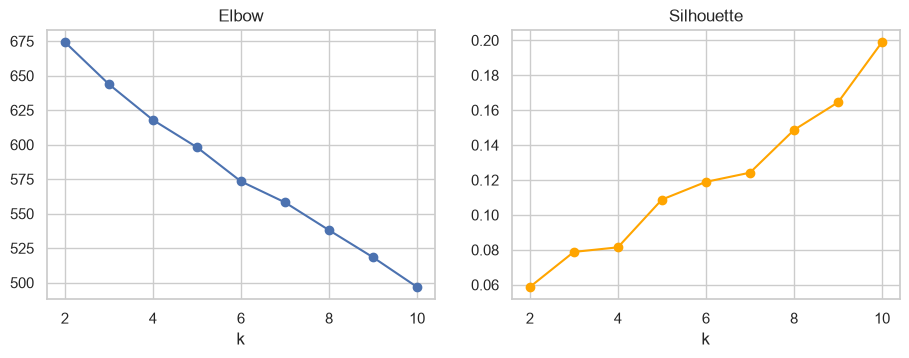

In [3]:
ks, inertia, sil = range(2, 11), [], []
for k in ks:
    km = KMeans(k, n_init=20, random_state=42).fit(Z)
    inertia.append(km.inertia_); sil.append(silhouette_score(Z, km.labels_))
fig, (a, b) = plt.subplots(1, 2, figsize=(11, 3.5))
a.plot(ks, inertia, "o-"); a.set(title="Elbow", xlabel="k")
b.plot(ks, sil, "o-", c="orange"); b.set(title="Silhouette", xlabel="k"); plt.show()

The silhouette score keeps rising slowly (typical for text), and there is no sharp elbow. We take the best k between **4 and 8** so the archetypes stay interpretable.

In [4]:
k = max(range(4, 9), key=lambda k: sil[k - 2]); print("chosen k =", k)
km = KMeans(k, n_init=20, random_state=42).fit(Z); fake["cluster"] = km.labels_
vocab = pipe.named_steps["tfidf"].get_feature_names_out()
centroids = km.cluster_centers_ @ pipe.named_steps["svd"].components_
pd.DataFrame([{"cluster": c, "size": (km.labels_ == c).sum(),
               "top terms": ", ".join(vocab[np.argsort(centroids[c])[::-1][:10]]),
               "example title": fake[fake.cluster == c].title.value_counts().index[0]} for c in range(k)])

chosen k = 8


,cluster,size,top terms,example title
0,0,34,"cash, free, day, extra, dollars, start, required, zero, fee, earn",Urgent Jobs (Part Time Workers Needed)
1,1,222,"sales, money, dollars, service, looking, business, urltoken, people, income,...",Customer Service Representative
2,2,73,"bonus, recruiting, signing, candidates, aptitude, product, new, software, re...",Senior Engineering Product Manager
3,3,46,"started, start, entry, internet, typing, home, need, access, earn, dollars",Home Based Payroll Typist/Data Entry Clerks Positions Available
4,4,52,"aker, gas, oil, global, engineering, solutions, colleagues, future, producti...",Lead Mechanical Engineer
5,5,232,"administrative, assistant, entry, office, data, customer, position, duties, ...",Data Entry Admin/Clerical Positions - Work From Home
6,6,186,"management, years, project, engineering, services, quality, requirements, ma...",Executive Chef
7,7,21,"cruise, board, ultra, free, tax, luxury, wanting, speaker, en, visa",Cruise Staff Wanted *URGENT*


## 2. Visualise with PCA

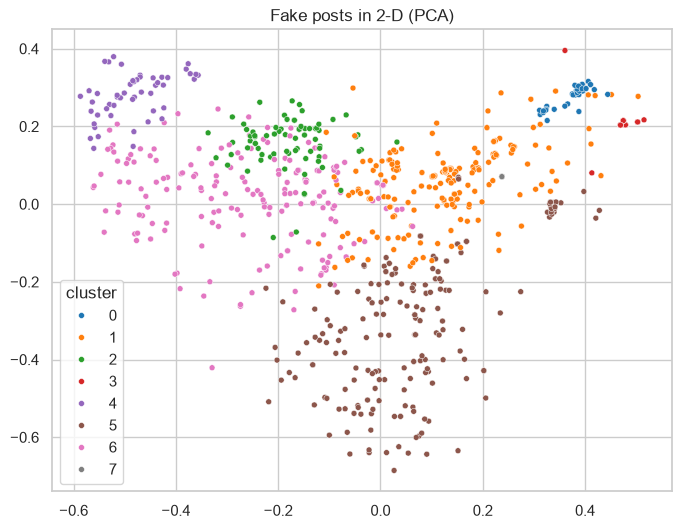

In [5]:
xy = PCA(2, random_state=42).fit_transform(Z)
plt.figure(figsize=(8, 6)); sns.scatterplot(x=xy[:, 0], y=xy[:, 1], hue=fake.cluster, palette="tab10", s=18)
plt.title("Fake posts in 2-D (PCA)"); plt.show()

## 3. Named archetypes (from `src/cluster.py`)

In [6]:
c = json.loads((ROOT / "reports/clusters.json").read_text())
pd.DataFrame(c["clusters"])[["name", "size", "top_terms", "telecommuting_rate", "no_logo_rate"]]

,name,size,top_terms,telecommuting_rate,no_logo_rate
0,Easy cash / get-rich-quick,34,"[cash, free, day, extra, dollars, start, zero, fee, earn, suitable, totally,...",0.000000,1.000000
1,Income opportunity / MLM-style sales,222,"[sales, money, dollars, service, looking, business, people, income, paid, cu...",0.108108,0.603604
2,Fake recruiter & signing bonus,73,"[bonus, recruiting, signing, candidates, aptitude, product, software, referr...",0.013699,0.068493
3,Work-from-home typing / online jobs,46,"[started, start, entry, internet, typing, home, need, access, earn, dollars,...",0.021739,1.000000
4,Oil & gas jobs abroad,52,"[aker, gas, oil, global, engineering, solutions, colleagues, future, product...",0.000000,0.403846
5,Admin / data entry / accounting,232,"[administrative, assistant, entry, office, data, customer, duties, accountin...",0.159483,0.905172
6,Professional roles (copied real ads),186,"[management, years, project, engineering, services, quality, manager, techni...",0.005376,0.602151
7,Cruise ship & hospitality,21,"[cruise, board, ultra, free, tax, luxury, wanting, speaker, en, visa, wifi, ...",0.000000,1.000000


## Findings
K-Means separates the scams into recognisable types: admin/data entry, MLM-style income, fake recruiters, oil & gas jobs abroad, work-from-home typing, easy cash and cruise jobs. The app uses this model to tell users which pattern a suspicious post resembles.